# 布朗运动

In [ ]:
*-setting
global path "D:/github_lianxh/FinE"
cd "$path/body/Brown-Ito/figures"

set scheme scientific

D:\github_lianxh\FinE\body\Brown-Ito\figures


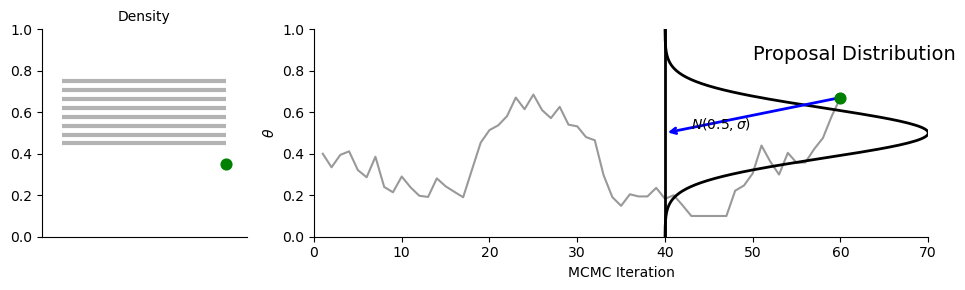

In [ ]:
# https://chatgpt.com/share/69241b9e-33b0-8005-89a2-fdb9dd2e4790

import numpy as np
import matplotlib.pyplot as plt

# 为了结果可重复
np.random.seed(123)

#------------------------------------------------------
# 1. 创建画布：两列子图，左窄右宽
#------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 3),
    gridspec_kw={"width_ratios": [1, 3]}
)

#------------------------------------------------------
# 2. 左图：Density 面板
#------------------------------------------------------
# 8 条水平“密度条”所在的纵坐标（θ）
y_lines = np.linspace(0.45, 0.75, 8)

# 画水平线
for y in y_lines:
    # hlines(y, xmin, xmax) 画水平线
    ax1.hlines(y, 0.1, 0.9, linewidth=3, color="0.7")

# 右侧绿色点，表示当前状态
ax1.scatter(0.9, 0.35, s=60, color="green", zorder=5)

# 设置轴范围和刻度
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_title("Density", fontsize=10)

# 左图主要是示意，因此把横轴刻度去掉，只保留纵轴 0-1 刻度
ax1.set_xticks([])
ax1.set_yticks(np.linspace(0, 1, 6))

# 去掉坐标轴上多余的边框效果
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

#------------------------------------------------------
# 3. 右图：MCMC 轨迹 + 提议分布
#------------------------------------------------------
# 3.1 生成一条简单的 MCMC 随机游走轨迹
n_iter = 60
iters = np.arange(1, n_iter + 1)

theta_trace = np.zeros(n_iter)
theta_trace[0] = 0.4  # 初始值

for t in range(1, n_iter):
    # 简单随机游走：上一期加一个正态扰动
    theta_trace[t] = theta_trace[t-1] + 0.06 * np.random.randn()

# 把 θ 限制在 [0.1, 0.9]，避免跑出图外
theta_trace = np.clip(theta_trace, 0.1, 0.9)

# 画出轨迹线
ax2.plot(iters, theta_trace, color="0.6", linewidth=1.5)

# 当前状态（轨迹的最后一个点）
theta_curr = theta_trace[-1]
iter_curr = iters[-1]
ax2.scatter(iter_curr, theta_curr, color="green", s=60, zorder=5)

# 3.2 构造“侧着画”的正态提议分布 N(0.5, σ)
theta_grid = np.linspace(0.0, 1.0, 200)  # 纵轴上的网格点
mu = 0.5
sigma = 0.12

# 手写正态密度函数（不用依赖 SciPy）
pdf = (1.0 / (sigma * np.sqrt(2 * np.pi))) * \
      np.exp(-0.5 * ((theta_grid - mu) / sigma) ** 2)

# 把 pdf 标准化到 [0, 1] 区间，再放大到合适的水平宽度
pdf = pdf / pdf.max()
x0 = 40.0      # 竖线的横坐标位置
scale = 30.0   # 控制“胖瘦”
x_pdf = x0 + scale * pdf

# 在 x = x0 画一条竖直参考线
ax2.axvline(x0, color="black", linewidth=2)

# 用 (x_pdf, theta_grid) 画出侧向的正态密度曲线
ax2.plot(x_pdf, theta_grid, color="black", linewidth=2)

# 3.3 当前状态到提议值的蓝色箭头
ax2.annotate(
    "",                        # 不写文字，只画箭头
    xy=(x0, mu),               # 箭头指向：提议均值 μ=0.5
    xytext=(iter_curr, theta_curr),  # 箭头起点：当前状态
    arrowprops=dict(arrowstyle="->", lw=2, color="blue")
)

# 3.4 添加文字说明
ax2.text(x0 + 3, mu + 0.02, r"$N(0.5,\sigma)$",
         fontsize=10, color="black")
ax2.text(50, 0.85, "Proposal Distribution",
         fontsize=14, color="black")

# 坐标轴设置
ax2.set_xlim(0, 70)
ax2.set_ylim(0, 1)
ax2.set_xlabel("MCMC Iteration")
ax2.set_ylabel(r"$\theta$")

ax2.set_yticks(np.linspace(0, 1, 6))
ax2.set_xticks(np.arange(0, 71, 10))

for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


Number of observations (_N) was 0, now 1,000.
file Brown_motion_simple_01.png written in PNG format


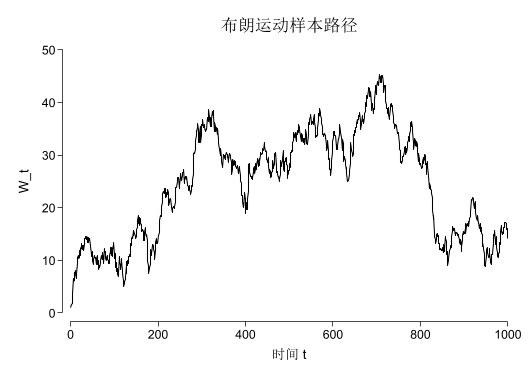

In [ ]:
*-Simple Brown motion

clear all
set seed 12345
set obs 1000
gen t = _n - 1
gen h = 1
gen dW = rnormal(0, sqrt(h))  // 生成增量，服从 N(0,h)
gen W = sum(dW)               // 累加增量，得到布朗运动
twoway line W t, title("布朗运动样本路径") ///
    ytitle("W_t") xtitle("时间 t")
graph export "Brown_motion_simple_01.png", replace width(600)

##提示词
- 二维布朗运动模拟及绘图
- Stata 代码
- seed 12345
- set obs 200


Number of observations (_N) was 0, now 100.


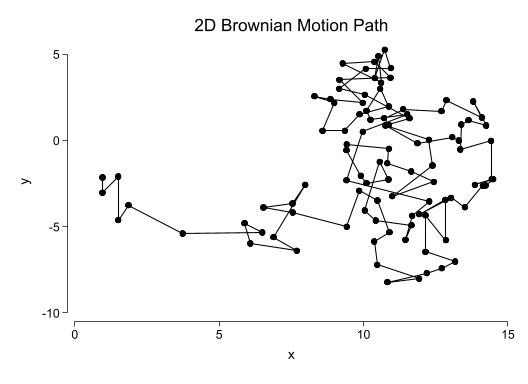

In [ ]:
* 二维布朗运动模拟与绘图示例
* 设定随机数种子和样本量
clear all
set seed 12345
set obs 100

gen t = _n   // t 为时间步（1, 2, ..., 200）

* 产生二维布朗运动的增量：
* dx, dy ~ N(0, 1)，后续取累积和得到路径
gen dx = rnormal(0, 1)
gen dy = rnormal(0, 1)

* 对增量求累积和，得到二维布朗运动的坐标 (x_t, y_t)
gen x = sum(dx)
gen y = sum(dy)

* 为了保证连线顺序按时间推进，按 t 排序
sort t

* 绘制二维布朗运动轨迹图（平面路径）
twoway connect y x, title("2D Brownian Motion Path")


从 (0, 0) 出发的二维标准维纳过程 (W_x(t), W_y(t)) 的模拟代码如下：

Number of observations (_N) was 0, now 500.
(500 missing values generated)
(500 missing values generated)
(1 real change made)
(1 real change made)
(499 real changes made)
(499 real changes made)
(note:  named style 1 not found in class connectstyle, default attributes
    used)


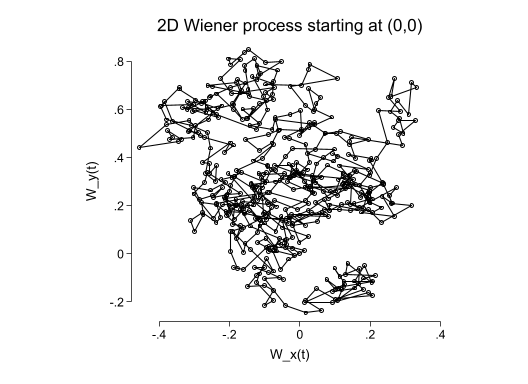

In [ ]:
* 二维标准维纳过程：从 (0,0) 出发
clear all
set seed 1234
set obs 500

* 总样本数 N，用于计算时间步长 dt = 1/(N-1)
local N = _N
scalar dt = 1/(`N' - 1)

* 时间变量：t_1 = 0, t_N = 1
gen t = (_n - 1)*dt

* 生成增量 dW_x, dW_y
* 标准维纳过程要求：增量 ~ N(0, dt)
gen dWx = .
gen dWy = .

* 第 1 个观测对应 t = 0，设增量为 0，保证 W(0) = 0
replace dWx = 0 in 1
replace dWy = 0 in 1

* 从第 2 个观测开始生成随机增量
replace dWx = rnormal(0, sqrt(dt)) in 2/`N'
replace dWy = rnormal(0, sqrt(dt)) in 2/`N'

* 对增量累积求和：得到维纳过程 W_x(t), W_y(t)
gen Wx = sum(dWx)
gen Wy = sum(dWy)

sort t

* 绘制二维维纳过程路径，从 (0,0) 开始
twoway ///
    (scatter Wy Wx, msymbol(oh) connect(1)) ///
    , ///
    xtitle("W_x(t)") ///
    ytitle("W_y(t)") ///
    title("2D Wiener process starting at (0,0)") ///
    aspect(0.8) 


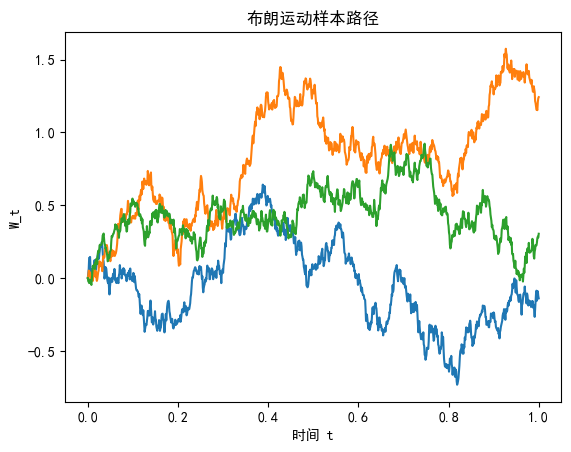

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号

def brownian_motion(T, N, M):
    dt = T / N
    dW = np.random.normal(0, np.sqrt(dt), (M, N))
    W = np.cumsum(dW, axis=1)
    W = np.hstack((np.zeros((M, 1)), W))
    return W
T = 1.0
N = 1000
M = 3
W = brownian_motion(T, N, M)
t = np.linspace(0, T, N+1)
for i in range(M):
    plt.plot(t, W[i])
plt.title("布朗运动样本路径")
plt.xlabel("时间 t")
plt.ylabel("W_t")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 2D Brownian motion - single trajectory
def generate_brownian_motion(n_steps, dt):
    # Generate random increments
    dx = np.random.normal(0, np.sqrt(dt), n_steps)
    dy = np.random.normal(0, np.sqrt(dt), n_steps)
    
    # Calculate cumulative sum to get positions
    x = np.cumsum(dx)
    y = np.cumsum(dy)
    
    # Add starting point at origin
    x = np.insert(x, 0, 0)
    y = np.insert(y, 0, 0)
    
    return x, y

(-1.4427323122570916,
 0.5380988937918919,
 -0.092544919684514,
 1.9434433133747941)

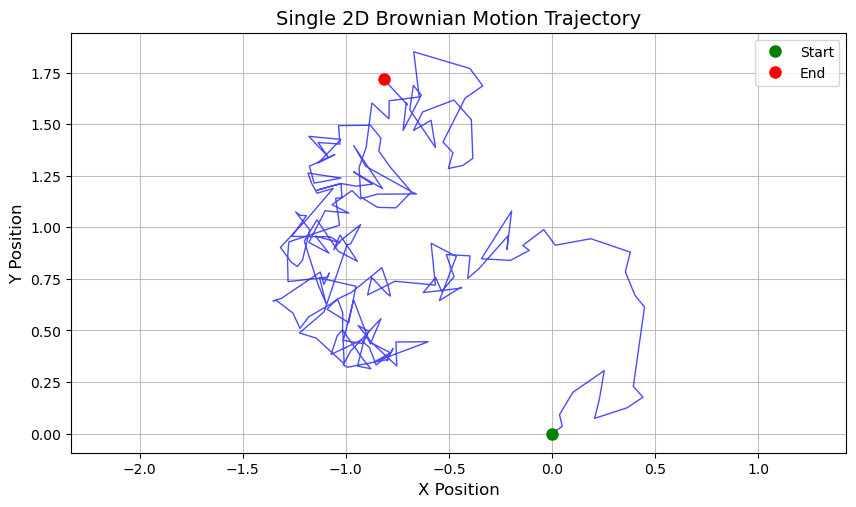

In [ ]:
# Figure 1: Single 2D Brownian motion trajectory

# Set random seed for reproducibility
np.random.seed(42)
# Parameters for Brownian motion
n_steps = 200
dt = 0.01

plt.figure(figsize=(10, 12))
x, y = generate_brownian_motion(n_steps, dt)

plt.subplot(2, 1, 1)
plt.plot(x, y, 'b-', alpha=0.7, linewidth=1)
plt.plot(x[0], y[0], 'go', markersize=8, label='Start')
plt.plot(x[-1], y[-1], 'ro', markersize=8, label='End')
plt.title('Single 2D Brownian Motion Trajectory', fontsize=14)
plt.xlabel('X Position', fontsize=12)
plt.ylabel('Y Position', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.5)
plt.axis('equal')


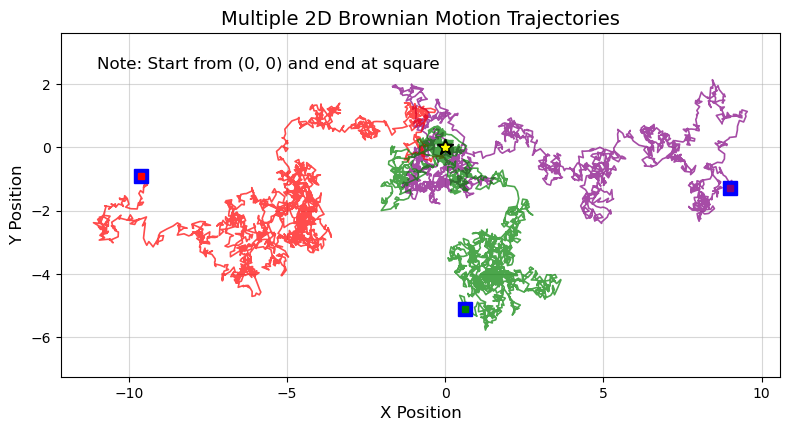

In [ ]:
# Figure 2: Multiple 2D Brownian motion trajectories

# Set random seed for reproducibility
np.random.seed(42)
# Parameters for Brownian motion
n_steps = 2000
dt = 0.01

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 2)
colors = ['purple', 'red', 'green']
n_trajectories = len(colors)

for i in range(n_trajectories):
    x, y = generate_brownian_motion(n_steps, dt)
    plt.plot(x, y, color=colors[i], alpha=0.7, linewidth=1.2, label=f'Trajectory {i+1}')
    plt.plot(x[0], y[0], 'o', color=colors[i], markersize=6)
    plt.plot(x[-1], y[-1], 's', color=colors[i], markersize=6)
    plt.plot(x[0], y[0], '*', color='black', markersize=12)
    plt.plot(x[0], y[0], '*', color='yellow', markersize=6)
    plt.plot(x[-1], y[-1], 's', color='blue', markersize=10)
    plt.plot(x[-1], y[-1], 's', color=colors[i], markersize=5)
plt.title('Multiple 2D Brownian Motion Trajectories', fontsize=14)
plt.xlabel('X Position', fontsize=12)
plt.ylabel('Y Position', fontsize=12)
plt.grid(True, alpha=0.5)
plt.axis('equal')
#add text: 'Start from (0, 0) and end at square' at West-North of the figure
plt.text(-11, 2.5, 'Note: Start from (0, 0) and end at square', fontsize=12, ha='left', color='black')

plt.tight_layout()

#保存到 figures 文件夹中，name='Brownian_Motion_step200-2000_01.png', dpi=300
plt.savefig('figures/Brownian_Motion_step200-ThreeLines-01.png', dpi=300)

plt.show()

绘制一幅图，演示布朗运动的轨迹：
1. 左图：二维布朗运动轨迹图，一条轨迹图，起点用圆点标注，终点用方块标注，Steps = 200
2. 右图：二维布朗运动轨迹图，多条轨迹图（例如 3 条），起点用圆点标注，终点用方块标注，Steps = 2000
3. 合理控制图形尺寸，确保插入 A4 文档时清晰可见，且字号与 12pt 正文字号相当

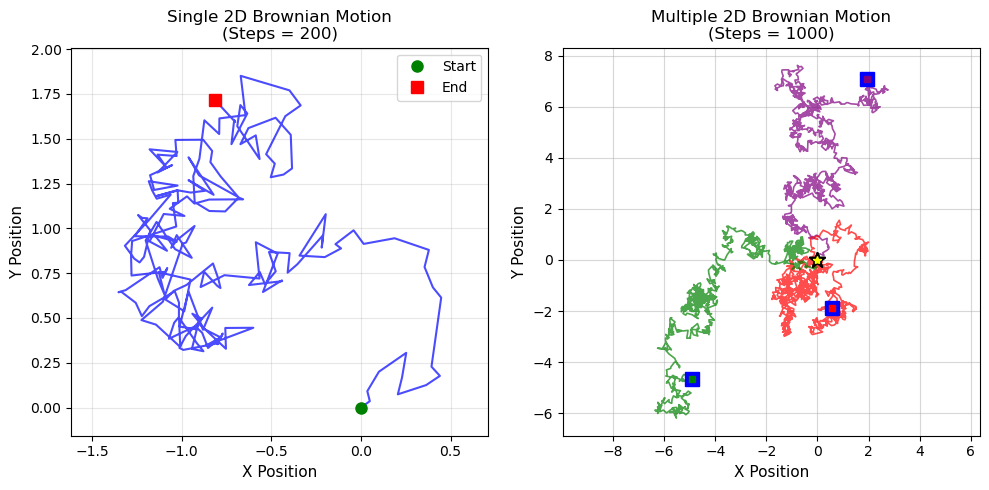

In [ ]:
# Create a figure with two subplots side by side
plt.figure(figsize=(10, 5))

# Left subplot: Single trajectory with 200 steps
plt.subplot(1, 2, 1)
np.random.seed(42)
x_single, y_single = generate_brownian_motion(200, 0.01)
plt.plot(x_single, y_single, 'b-', alpha=0.7, linewidth=1.5)
plt.plot(x_single[0], y_single[0], 'go', markersize=8, label='Start')
plt.plot(x_single[-1], y_single[-1], 'rs', markersize=8, label='End')
plt.title('Single 2D Brownian Motion\n(Steps = 200)', fontsize=12)
plt.xlabel('X Position', fontsize=11)
plt.ylabel('Y Position', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Right subplot: Multiple trajectories with 2000 steps
plt.subplot(1, 2, 2)
np.random.seed(42)
colors = ['purple', 'red', 'green']

for i in range(3):
    x_multi, y_multi = generate_brownian_motion(1000, 0.01)
    plt.plot(x_multi, y_multi, color=colors[i], alpha=0.7, linewidth=1.2, label=f'Trajectory {i+1}')
    plt.plot(x_multi[0],  y_multi[0], '*', color='black', markersize=12)
    plt.plot(x_multi[0],  y_multi[0], '*', color='yellow', markersize=6)
    plt.plot(x_multi[-1], y_multi[-1], 's', color='blue', markersize=10)
    plt.plot(x_multi[-1], y_multi[-1], 's', color=colors[i], markersize=5)
plt.title('Multiple 2D Brownian Motion\n(Steps = 1000)', fontsize=12)
plt.xlabel('X Position', fontsize=11)
plt.ylabel('Y Position', fontsize=11)
plt.grid(True, alpha=0.5)
plt.axis('equal')

plt.tight_layout()

#保存到 figures 文件夹中，name='Brownian_Motion_step200-1000_01.png', dpi=300
plt.savefig('figures/Brownian_Motion_step200-1000_01.png', dpi=300)

plt.show()

Python 代码，可以独立运行。绘图展示不同 Steps 取值时 (其它条件相同)，三个服从布朗运动的序列的变化轨迹：
- 左图：Step2 = 1000
- 中图：Step2 = 10000
- 右图：Step3 = 100000
可以先生成 Step3 = 100000 的布朗运动序列，然后通过截取前面的数据，得到 Step2 = 10000 和 Step1 = 1000 的布朗运动序列。

编写一组中文提示词，以便我的学生可以根据这些提示词生成下一个 block 中的代码。

# Figure 2: Multiple 2D Brownian motion trajectories


"""
提示词：
1. 创建一个包含三个子图的水平排列图形，图形尺寸为 (15, 5)
2. 设置三种不同的步数：1000步、1200步、100000步
3. 使用相同的时间步长 dt = 0.01 和相同的随机种子确保结果可重现
4. 先生成 100000 步的完整轨迹，然后通过截取前 N 步的方式获得较短的轨迹
5. 为每个子图绘制3条不同颜色的布朗运动轨迹（紫色、红色、绿色）
6. 用圆点标记起点，用方块标记终点
7. 为每个子图添加标题显示对应的步数
8. 添加坐标轴标签和网格线，保持各子图的纵横比相等
9. 只在第一个子图添加图例说明
10. 使用 tight_layout() 调整布局并显示图形

核心概念：
- 通过截取同一组长轨迹的不同长度来确保公平比较
- 展示步数对布朗运动轨迹复杂度和扩散范围的影响
- 保持其他参数（dt、随机种子、颜色等）完全一致
"""

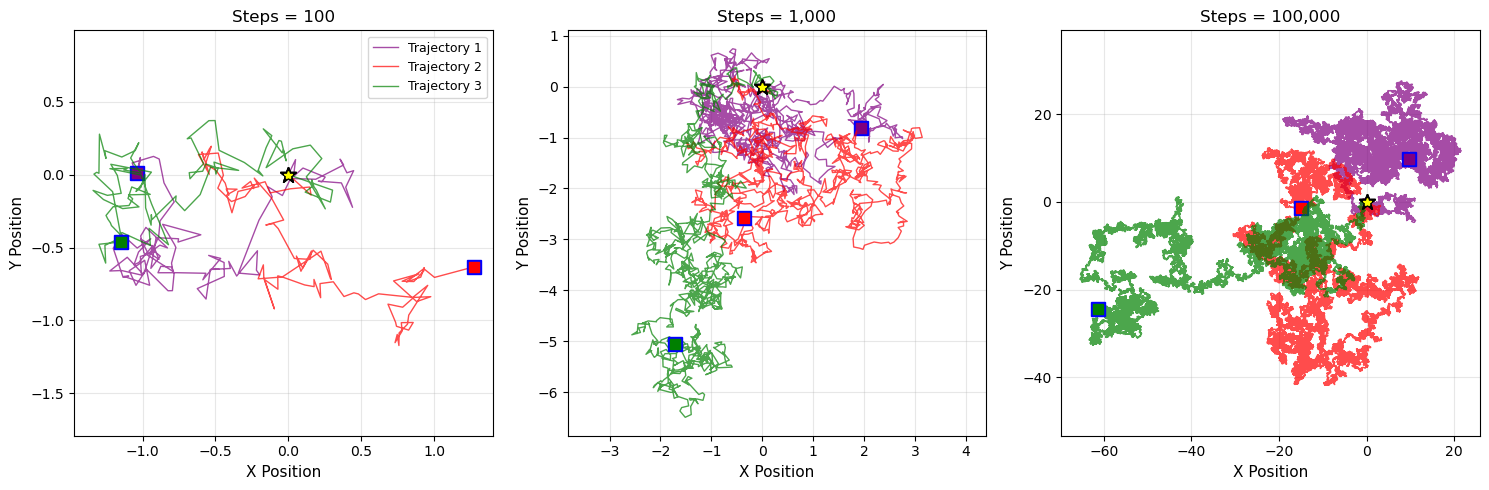

In [ ]:
# Generate the longest trajectory first (100,000 steps) and then truncate for shorter ones
plt.figure(figsize=(15, 5))

# Parameters
dt = 0.01
colors = ['purple', 'red', 'green']
step_counts = [100, 1000, 100000]
titles = ['Steps = 100', 'Steps = 1,000', 'Steps = 100,000']

# Set seed for reproducible results
np.random.seed(42)

# Generate 3 complete trajectories with 100,000 steps each
trajectories = []
for i in range(3):
    x_full, y_full = generate_brownian_motion(100000, dt)
    trajectories.append((x_full, y_full))

# Create subplots for different step counts
for subplot_idx, (steps, title) in enumerate(zip(step_counts, titles), 1):
    plt.subplot(1, 3, subplot_idx)
    
    # Plot each trajectory using truncated data
    for i in range(3):
        x_full, y_full = trajectories[i]
        # Truncate to desired number of steps
        x = x_full[:steps+1]  # +1 because we include the starting point
        y = y_full[:steps+1]
        
        plt.plot(x, y, color=colors[i], alpha=0.7, linewidth=1.0, label=f'Trajectory {i+1}')
        # 起点用圆点标记
        plt.plot(x[0], y[0], '*', color='black', markersize=12)
        plt.plot(x[0], y[0], '*', color='yellow', markersize=6)

        # 终点用方块标记
        plt.plot(x[-1], y[-1], 's', color='blue', markersize=10)
        plt.plot(x[-1], y[-1], 's', color=colors[i], markersize=7)
    
    plt.title(title, fontsize=12)
    plt.xlabel('X Position', fontsize=11)
    plt.ylabel('Y Position', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    
    # Add legend only to the first subplot
    if subplot_idx == 1:
        plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

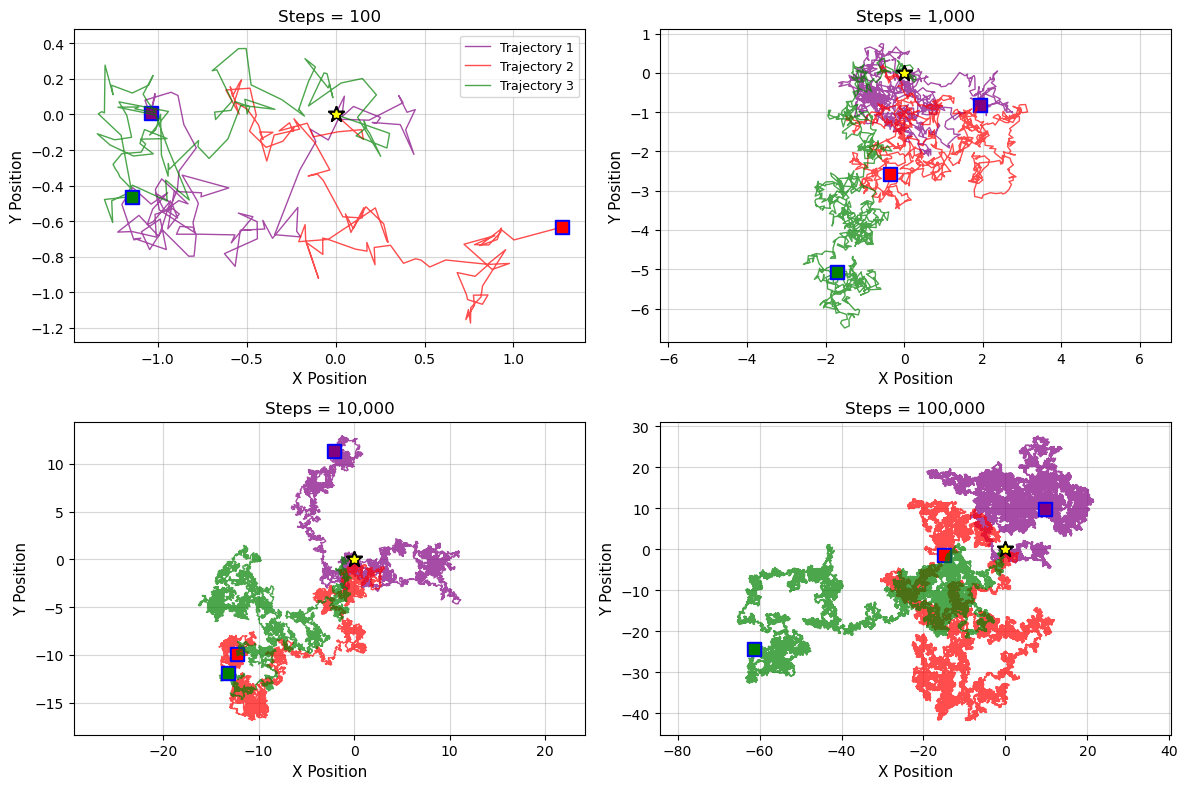

In [ ]:
# 先生成最长的一条轨迹 (100,000 步)，再通过截取得到较短轨迹
plt.figure(figsize=(12, 8))  # 2*2 子图，画布略大一点

# 参数设置
dt = 0.01
colors = ['purple', 'red', 'green']
step_counts = [100, 1000, 10000, 100000]
titles = ['Steps = 100', 'Steps = 1,000', 'Steps = 10,000', 'Steps = 100,000']

# 设定随机数种子，保证结果可重复
np.random.seed(42)

# 生成 3 条完整的 100,000 步二维布朗运动轨迹
trajectories = []
for i in range(4):
    x_full, y_full = generate_brownian_motion(100000, dt)
    trajectories.append((x_full, y_full))

# 针对不同的步数，绘制 2*2 子图
for subplot_idx, (steps, title) in enumerate(zip(step_counts, titles), 1):
    # 2 行 2 列的子图布局
    plt.subplot(2, 2, subplot_idx)
    
    # 对每一条完整轨迹进行截断并绘制
    for i in range(3):
        x_full, y_full = trajectories[i]
        # 截取前 steps+1 个点（包含起点）
        x = x_full[:steps+1]
        y = y_full[:steps+1]
        
        # 绘制路径
        plt.plot(
            x, y,
            color=colors[i],
            alpha=0.7,
            linewidth=1.0,
            label=f'Trajectory {i+1}'
        )
        # 起点用圆点标记
        plt.plot(x[0], y[0], '*', color='black', markersize=12)
        plt.plot(x[0], y[0], '*', color='yellow', markersize=6)

        # 终点用方块标记
        plt.plot(x[-1], y[-1], 's', color='blue', markersize=10)
        plt.plot(x[-1], y[-1], 's', color=colors[i], markersize=7)
    
    plt.title(title, fontsize=12)
    plt.xlabel('X Position', fontsize=11)
    plt.ylabel('Y Position', fontsize=11)
    plt.grid(True, alpha=0.5)
    plt.axis('equal')  # 保持 x、y 比例一致
    
    # 只在第一个子图中添加图例，避免重复
    if subplot_idx == 1:
        plt.legend(fontsize=9, loc='best')

plt.tight_layout()
plt.show()


### 提示词

帮我解释从上图中能得到的核心结论，比如：布朗序列的方差随着步数增加而增加，轨迹变得更加复杂和分散。方差是否有限？或者说方差有何规律？